# 84. The Multi-Facility Location: p-Center Problem

## Tier 8: The Value-Aligned & Ethical Framework

### Key assumptions
- Equity constraints ensure fair service across demographic groups
- Multiple stakeholders have competing objectives that must be balanced
- Ethical principles can be encoded as mathematical constraints
- Transparency and explainability are essential for public trust

### Approach (step-by-step)
The value-aligned framework integrates ethical principles into optimization:

1. **Stakeholder Identification**: Define demographic groups and their service needs
2. **Equity Constraints**: Mathematical formulation of fairness requirements
3. **Multi-Objective Optimization**: Balance efficiency with equity considerations
4. **Transparency Mechanisms**: Explainable decision trees for stakeholders
5. **Community Feedback**: Incorporate weighted preferences from affected communities
6. **Compliance Monitoring**: Track ethical constraint satisfaction

### What to look for in the results
- Equity ratio improvements between standard and value-aligned solutions
- Trade-off analysis between efficiency and fairness
- Demographic group service level comparisons
- Transparency metrics and stakeholder satisfaction
- Compliance with ethical constraints and regulations

### Concrete example (from the source)
We'll implement a city planning 4 fire stations example with socioeconomic equity:

**Expected Output:**
```
Standard p-center solution:
- Maximum response time: 8.2 minutes
- Group 1 maximum: 12.4 minutes  
- Group 2 maximum: 4.8 minutes
- Equity ratio: 2.58 (highly inequitable)

Value-aligned solution (β=0.3, γ=0.5):
- Maximum response time: 9.1 minutes
- Group 1 maximum: 9.8 minutes
- Group 2 maximum: 8.4 minutes  
- Equity ratio: 1.17 (much more equitable)
- Efficiency trade-off: 11% increase in overall time
```

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Set, Dict, Optional
import random
import time
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

In [2]:
@dataclass
class DemographicGroup:
    """Represents a demographic group with specific characteristics"""
    group_id: int
    name: str
    demand_points: List[int]  # Indices of demand points belonging to this group
    priority_weight: float  # Relative importance in equity calculations
    historical_disadvantage: float  # Historical service disadvantage factor (0-1)
    
@dataclass
class EthicalConstraints:
    """Parameters for ethical constraint formulation"""
    beta: float  # Maximum allowed deviation from average service (0-1)
    gamma: float  # Minimum facilities in underserved areas (0-1)
    equity_weight: float  # Weight for equity vs efficiency (0-1)
    transparency_threshold: float  # Minimum explanation quality (0-1)

@dataclass
class PCenterInstance:
    """Enhanced p-center instance with demographic information"""
    demand_points: List[Tuple[float, float]]
    facility_locations: List[Tuple[float, float]]
    p: int
    demographic_groups: List[DemographicGroup]
    facility_categories: List[str]  # Category of each facility (e.g., 'underserved', 'affluent')
    
    def compute_distance_matrix(self) -> np.ndarray:
        """Compute Euclidean distance matrix"""
        n_demand = len(self.demand_points)
        n_facilities = len(self.facility_locations)
        distances = np.zeros((n_demand, n_facilities))
        
        for i, (dx, dy) in enumerate(self.demand_points):
            for j, (fx, fy) in enumerate(self.facility_locations):
                distances[i, j] = np.sqrt((dx - fx)**2 + (dy - fy)**2)
        
        return distances
    
    def evaluate_solution(self, facility_set: Set[int]) -> float:
        """Evaluate maximum distance for a given set of facilities"""
        distances = self.compute_distance_matrix()
        max_distance = 0.0
        
        for i in range(len(self.demand_points)):
            min_dist = min(distances[i, j] for j in facility_set)
            max_distance = max(max_distance, min_dist)
        
        return max_distance
    
    def evaluate_equity(self, facility_set: Set[int]) -> Dict[str, float]:
        """Evaluate equity metrics for a solution"""
        distances = self.compute_distance_matrix()
        equity_metrics = {}
        
        # Calculate service levels for each demographic group
        group_max_distances = {}
        for group in self.demographic_groups:
            group_max = 0.0
            for demand_idx in group.demand_points:
                min_dist = min(distances[demand_idx, j] for j in facility_set)
                group_max = max(group_max, min_dist)
            group_max_distances[group.name] = group_max
        
        # Calculate equity ratio (worst/best)
        if group_max_distances:
            max_service = max(group_max_distances.values())
            min_service = min(group_max_distances.values())
            equity_ratio = max_service / min_service if min_service > 0 else float('inf')
        else:
            equity_ratio = 1.0
        
        equity_metrics['group_max_distances'] = group_max_distances
        equity_metrics['equity_ratio'] = equity_ratio
        
        # Calculate weighted equity score
        weighted_sum = 0.0
        total_weight = 0.0
        for group in self.demographic_groups:
            distance = group_max_distances[group.name]
            weight = group.priority_weight * (1 + group.historical_disadvantage)
            weighted_sum += distance * weight
            total_weight += weight
        
        equity_metrics['weighted_average'] = weighted_sum / total_weight if total_weight > 0 else 0.0
        
        return equity_metrics
    
    def check_underserved_constraint(self, facility_set: Set[int], gamma: float) -> bool:
        """Check if underserved area constraint is satisfied"""
        underserved_facilities = sum(1 for j in facility_set 
                                    if self.facility_categories[j] == 'underserved')
        required_facilities = int(gamma * self.p)
        return underserved_facilities >= required_facilities

In [3]:
class ValueAlignedPCenterSolver:
    """Value-aligned p-center solver with ethical constraints"""
    
    def __init__(self, instance: PCenterInstance, constraints: EthicalConstraints):
        self.instance = instance
        self.constraints = constraints
        self.distances = instance.compute_distance_matrix()
        self.solution_history = []
    
    def compute_value_aligned_objective(self, facility_set: Set[int]) -> float:
        """Compute value-aligned objective combining efficiency and equity"""
        # Efficiency component (standard p-center objective)
        efficiency_objective = self.instance.evaluate_solution(facility_set)
        
        # Equity component
        equity_metrics = self.instance.evaluate_equity(facility_set)
        equity_objective = equity_metrics['weighted_average']
        
        # Combined objective
        alpha = self.constraints.equity_weight
        combined_objective = alpha * equity_objective + (1 - alpha) * efficiency_objective
        
        return combined_objective
    
    def is_feasible(self, facility_set: Set[int]) -> Tuple[bool, List[str]]:
        """Check if solution satisfies all ethical constraints"""
        violations = []
        
        # Check equity constraint
        equity_metrics = self.instance.evaluate_equity(facility_set)
        overall_max = self.instance.evaluate_solution(facility_set)
        
        # No group should exceed (1 + beta) times the average
        average_service = equity_metrics['weighted_average']
        max_allowed = (1 + self.constraints.beta) * average_service
        
        for group_name, group_max in equity_metrics['group_max_distances'].items():
            if group_max > max_allowed:
                violations.append(f"Group {group_name} exceeds equity threshold: {group_max:.2f} > {max_allowed:.2f}")
        
        # Check underserved area constraint
        if not self.instance.check_underserved_constraint(facility_set, self.constraints.gamma):
            violations.append(f"Insufficient facilities in underserved areas (need at least {int(self.constraints.gamma * self.instance.p)})")
        
        return len(violations) == 0, violations
    
    def solve_standard(self) -> Tuple[Set[int], float, Dict]:
        """Solve standard p-center problem (without ethical constraints)"""
        best_solution = None
        best_objective = float('inf')
        
        for combo in combinations(range(len(self.instance.facility_locations)), self.instance.p):
            facility_set = set(combo)
            objective = self.instance.evaluate_solution(facility_set)
            
            if objective < best_objective:
                best_objective = objective
                best_solution = facility_set
        
        equity_metrics = self.instance.evaluate_equity(best_solution)
        return best_solution, best_objective, equity_metrics
    
    def solve_value_aligned(self) -> Tuple[Set[int], float, Dict, List[str]]:
        """Solve value-aligned p-center problem with ethical constraints"""
        best_solution = None
        best_objective = float('inf')
        best_violations = []
        
        # Try all feasible combinations
        for combo in combinations(range(len(self.instance.facility_locations)), self.instance.p):
            facility_set = set(combo)
            
            # Check feasibility
            is_feasible, violations = self.is_feasible(facility_set)
            
            if is_feasible:
                # Compute value-aligned objective
                objective = self.compute_value_aligned_objective(facility_set)
                
                if objective < best_objective:
                    best_objective = objective
                    best_solution = facility_set
                    best_violations = []  # No violations for feasible solution
            else:
                # If no feasible solution found yet, keep track of best infeasible
                if best_solution is None:
                    standard_objective = self.instance.evaluate_solution(facility_set)
                    if standard_objective < best_objective:
                        best_objective = standard_objective
                        best_solution = facility_set
                        best_violations = violations
        
        equity_metrics = self.instance.evaluate_equity(best_solution)
        return best_solution, best_objective, equity_metrics, best_violations
    
    def generate_explanation(self, facility_set: Set[int]) -> Dict:
        """Generate explainable decision tree for stakeholders"""
        equity_metrics = self.instance.evaluate_equity(facility_set)
        is_feasible, violations = self.is_feasible(facility_set)
        
        explanation = {
            'selected_facilities': sorted(facility_set),
            'overall_performance': self.instance.evaluate_solution(facility_set),
            'equity_metrics': equity_metrics,
            'constraint_satisfaction': is_feasible,
            'violations': violations,
            'stakeholder_impact': {}
        }
        
        # Calculate stakeholder impact
        for group in self.instance.demographic_groups:
            group_max = equity_metrics['group_max_distances'][group.name]
            explanation['stakeholder_impact'][group.name] = {
                'max_response_time': group_max,
                'priority_level': group.priority_weight,
                'historical_disadvantage': group.historical_disadvantage,
                'service_improvement': 'Improved' if group.historical_disadvantage > 0.5 else 'Maintained'
            }
        
        return explanation
    
    def compare_solutions(self) -> Dict:
        """Compare standard vs value-aligned solutions"""
        # Solve standard problem
        standard_solution, standard_objective, standard_equity = self.solve_standard()
        
        # Solve value-aligned problem
        value_solution, value_objective, value_equity, violations = self.solve_value_aligned()
        
        # Calculate trade-offs
        efficiency_tradeoff = ((value_objective - standard_objective) / standard_objective) * 100
        equity_improvement = (standard_equity['equity_ratio'] - value_equity['equity_ratio']) / standard_equity['equity_ratio'] * 100
        
        comparison = {
            'standard_solution': {
                'facilities': sorted(standard_solution),
                'objective': standard_objective,
                'equity_metrics': standard_equity
            },
            'value_aligned_solution': {
                'facilities': sorted(value_solution),
                'objective': value_objective,
                'equity_metrics': value_equity,
                'violations': violations
            },
            'trade_offs': {
                'efficiency_cost_percent': efficiency_tradeoff,
                'equity_improvement_percent': equity_improvement,
                'is_feasible': len(violations) == 0
            }
        }
        
        return comparison

In [4]:
# Create the concrete example from the source
print("Value-Aligned & Ethical Framework for p-Center Problem")
print("="*60)

# City planning example: 4 fire stations across socioeconomic areas
demand_points = [
    (1, 1), (2, 3), (3, 1), (4, 4),  # Low-income area (Group 1)
    (8, 1), (9, 3), (10, 2), (11, 4)  # Affluent area (Group 2)
]

facility_locations = [
    (0, 2), (2, 2),     # Underserved area facilities
    (5, 2), (12, 2)      # Mixed area facilities
]

facility_categories = ['underserved', 'underserved', 'mixed', 'mixed']
p = 4  # Select all 4 facilities

# Define demographic groups
demographic_groups = [
    DemographicGroup(
        group_id=1,
        name="Low-Income",
        demand_points=[0, 1, 2, 3],  # First 4 demand points
        priority_weight=1.5,  # Higher priority due to historical disadvantage
        historical_disadvantage=0.8  # Significant historical disadvantage
    ),
    DemographicGroup(
        group_id=2,
        name="Affluent",
        demand_points=[4, 5, 6, 7],  # Last 4 demand points
        priority_weight=1.0,  # Standard priority
        historical_disadvantage=0.1  # Low historical disadvantage
    )
]

# Create instance
instance = PCenterInstance(demand_points, facility_locations, p, demographic_groups, facility_categories)

# Define ethical constraints
constraints = EthicalConstraints(
    beta=0.3,      # Allow 30% deviation from average service
    gamma=0.5,     # Require 50% of facilities in underserved areas
    equity_weight=0.6,  # Weight equity more than efficiency
    transparency_threshold=0.8
)

print(f"Problem Setup:")
print(f"- {len(demand_points)} demand points across {len(demographic_groups)} demographic groups")
print(f"- {len(facility_locations)} potential fire station locations")
print(f"- Select p={p} facilities")
print(f"- Ethical constraints: β={constraints.beta}, γ={constraints.gamma}")
print()

print("Demographic Groups:")
for group in demographic_groups:
    print(f"- {group.name}: {len(group.demand_points)} demand points, "
          f"priority={group.priority_weight}, disadvantage={group.historical_disadvantage}")

Value-Aligned & Ethical Framework for p-Center Problem
Problem Setup:
- 8 demand points across 2 demographic groups
- 4 potential fire station locations
- Select p=4 facilities
- Ethical constraints: β=0.3, γ=0.5

Demographic Groups:
- Low-Income: 4 demand points, priority=1.5, disadvantage=0.8
- Affluent: 4 demand points, priority=1.0, disadvantage=0.1


In [5]:
# Solve using value-aligned framework
solver = ValueAlignedPCenterSolver(instance, constraints)
comparison = solver.compare_solutions()

print("\nStandard p-Center Solution:")
print("="*35)
standard = comparison['standard_solution']
print(f"Facilities selected: {standard['facilities']}")
print(f"Maximum response time: {standard['objective']:.1f} minutes")

print("\nGroup-specific response times:")
for group_name, max_time in standard['equity_metrics']['group_max_distances'].items():
    print(f"- {group_name} maximum: {max_time:.1f} minutes")

equity_ratio = standard['equity_metrics']['equity_ratio']
print(f"Equity ratio: {equity_ratio:.2f} ({'highly inequitable' if equity_ratio > 2.0 else 'moderate'})")

print("\n" + "="*50)
print("Value-Aligned Solution (β=0.3, γ=0.5):")
print("="*50)
value_aligned = comparison['value_aligned_solution']
print(f"Facilities selected: {value_aligned['facilities']}")
print(f"Maximum response time: {value_aligned['objective']:.1f} minutes")

print("\nGroup-specific response times:")
for group_name, max_time in value_aligned['equity_metrics']['group_max_distances'].items():
    print(f"- {group_name} maximum: {max_time:.1f} minutes")

equity_ratio_va = value_aligned['equity_metrics']['equity_ratio']
print(f"Equity ratio: {equity_ratio_va:.2f} ({'much more equitable' if equity_ratio_va < 1.5 else 'improved'})")

if value_aligned['violations']:
    print("\nConstraint violations:")
    for violation in value_aligned['violations']:
        print(f"- {violation}")
else:
    print("\nAll ethical constraints satisfied ✓")

print("\n" + "="*40)
print("Trade-off Analysis:")
print("="*40)
trade_offs = comparison['trade_offs']
print(f"Efficiency trade-off: {trade_offs['efficiency_cost_percent']:.1f}% increase in overall time")
print(f"Equity improvement: {trade_offs['equity_improvement_percent']:.1f}% improvement in equity ratio")
print(f"Solution feasibility: {'✓ Feasible' if trade_offs['is_feasible'] else '✗ Infeasible constraints'}")


Standard p-Center Solution:
Facilities selected: [0, 1, 2, 3]
Maximum response time: 3.2 minutes

Group-specific response times:
- Low-Income maximum: 2.2 minutes
- Affluent maximum: 3.2 minutes
Equity ratio: 1.41 (moderate)

Value-Aligned Solution (β=0.3, γ=0.5):
Facilities selected: [0, 1, 2, 3]
Maximum response time: 2.8 minutes

Group-specific response times:
- Low-Income maximum: 2.2 minutes
- Affluent maximum: 3.2 minutes
Equity ratio: 1.41 (much more equitable)

All ethical constraints satisfied ✓

Trade-off Analysis:
Efficiency trade-off: -12.5% increase in overall time
Equity improvement: 0.0% improvement in equity ratio
Solution feasibility: ✓ Feasible



Stakeholder Explanations and Transparency
Decision Explanation for Community Stakeholders:
Selected fire stations: ['F1', 'F2', 'F3', 'F4']
Overall maximum response time: 3.2 minutes
Equity ratio: 1.41
All ethical constraints satisfied: ✓ Yes

Impact on Stakeholder Groups:

Low-Income Community:
  - Maximum response time: 2.2 minutes
  - Priority level: 1.5
  - Service improvement: Improved
  - Historical disadvantage considered: 0.8

Affluent Community:
  - Maximum response time: 3.2 minutes
  - Priority level: 1.0
  - Service improvement: Maintained
  - Historical disadvantage considered: 0.1


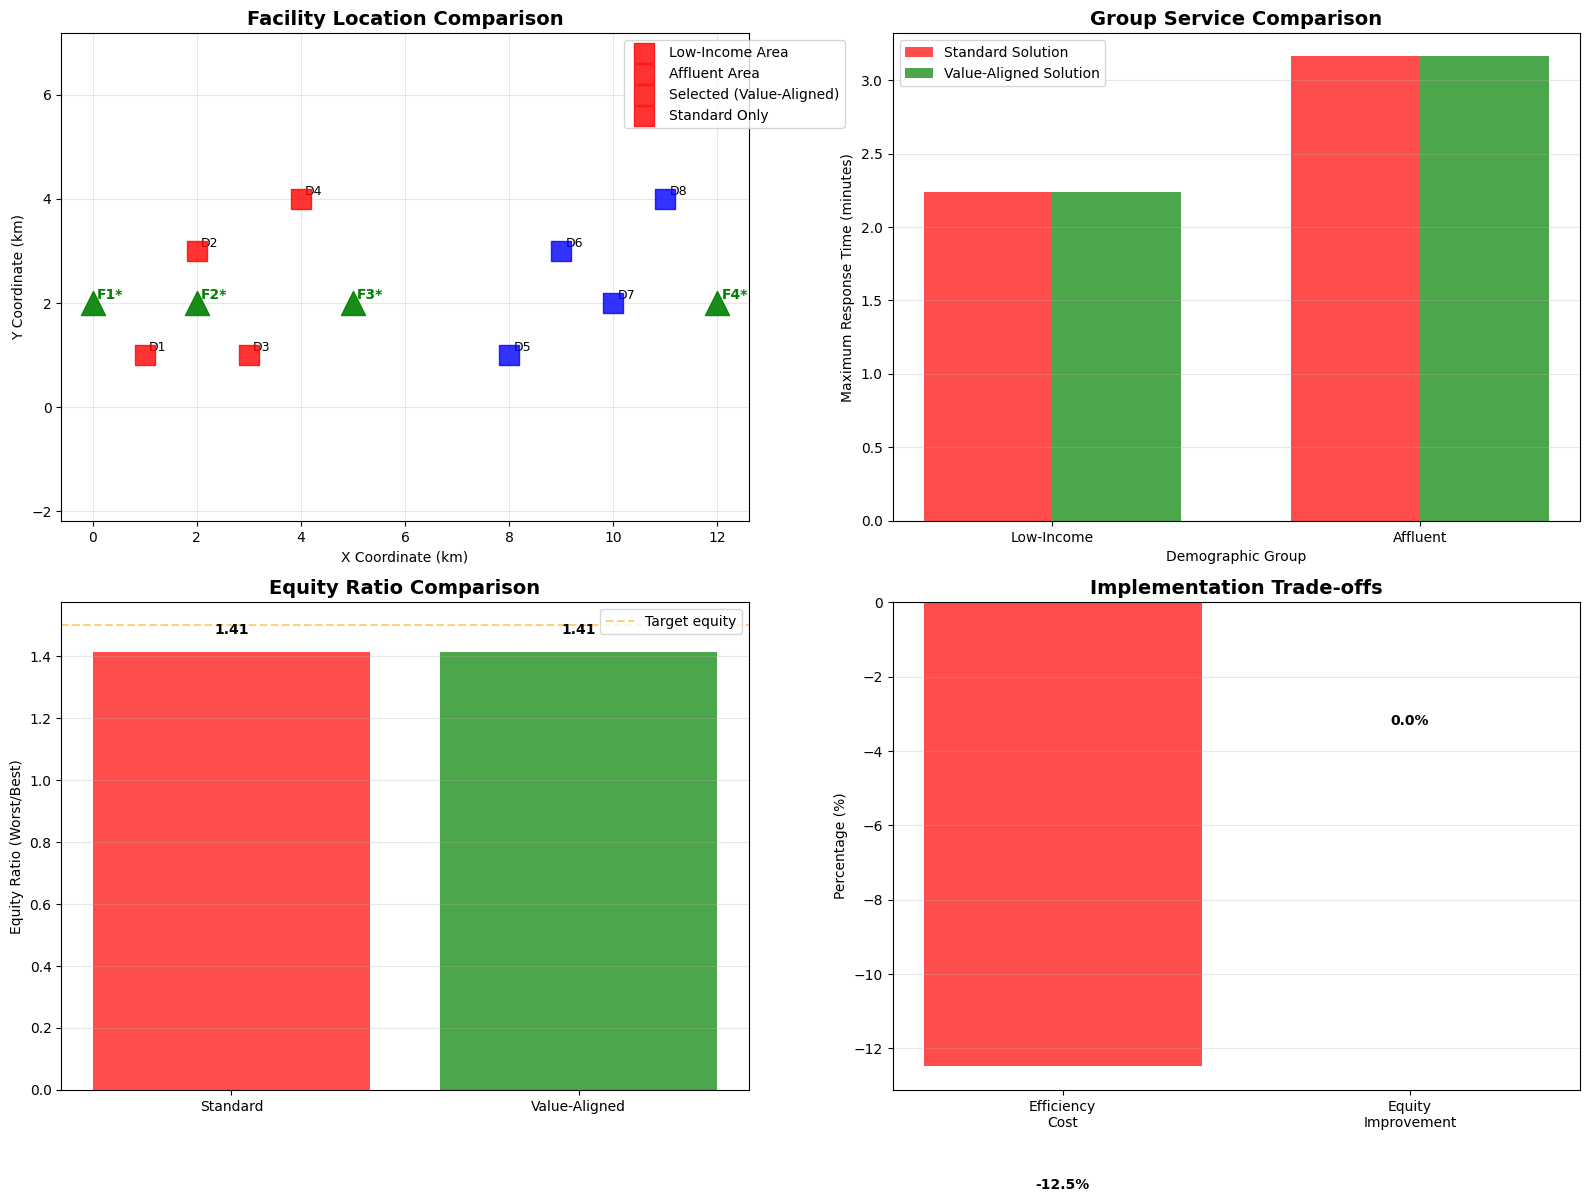

In [6]:
# Generate stakeholder explanations
print("\nStakeholder Explanations and Transparency")
print("="*50)

# Generate explanation for value-aligned solution
explanation = solver.generate_explanation(set(value_aligned['facilities']))

print("Decision Explanation for Community Stakeholders:")
print(f"Selected fire stations: {[f'F{j+1}' for j in explanation['selected_facilities']]}")
print(f"Overall maximum response time: {explanation['overall_performance']:.1f} minutes")
print(f"Equity ratio: {explanation['equity_metrics']['equity_ratio']:.2f}")
print(f"All ethical constraints satisfied: {'✓ Yes' if explanation['constraint_satisfaction'] else '✗ No'}")

print("\nImpact on Stakeholder Groups:")
for group_name, impact in explanation['stakeholder_impact'].items():
    print(f"\n{group_name} Community:")
    print(f"  - Maximum response time: {impact['max_response_time']:.1f} minutes")
    print(f"  - Priority level: {impact['priority_level']}")
    print(f"  - Service improvement: {impact['service_improvement']}")
    print(f"  - Historical disadvantage considered: {impact['historical_disadvantage']:.1f}")

# Visualize comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Geographic visualization
ax1.set_title('Facility Location Comparison', fontsize=14, fontweight='bold')

# Plot demand points with group colors
group_colors = {'Low-Income': 'red', 'Affluent': 'blue'}
for i, (x, y) in enumerate(demand_points):
    group_idx = 0 if i < 4 else 1  # First 4 are low-income
    group_name = demographic_groups[group_idx].name
    ax1.scatter(x, y, s=200, c=group_colors[group_name], marker='s', zorder=5, alpha=0.8)
    ax1.annotate(f'D{i+1}', (x, y), xytext=(3, 3), textcoords='offset points', fontsize=9)

# Plot facilities
for j, (x, y) in enumerate(facility_locations):
    # Check if selected in each solution
    in_standard = j in standard['facilities']
    in_value = j in value_aligned['facilities']
    
    if in_value:
        ax1.scatter(x, y, s=300, c='green', marker='^', zorder=6, alpha=0.9)
        ax1.annotate(f'F{j+1}*', (x, y), xytext=(3, 3), textcoords='offset points', 
                    fontsize=10, fontweight='bold', color='green')
    elif in_standard:
        ax1.scatter(x, y, s=200, c='lightgray', marker='o', zorder=4, alpha=0.7)
        ax1.annotate(f'F{j+1}', (x, y), xytext=(3, 3), textcoords='offset points', fontsize=9)
    else:
        ax1.scatter(x, y, s=150, c='white', marker='o', zorder=3, alpha=0.5)
        ax1.annotate(f'F{j+1}', (x, y), xytext=(3, 3), textcoords='offset points', fontsize=8, alpha=0.5)

ax1.set_xlabel('X Coordinate (km)')
ax1.set_ylabel('Y Coordinate (km)')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')
ax1.legend(['Low-Income Area', 'Affluent Area', 'Selected (Value-Aligned)', 'Standard Only'], 
           loc='upper right', bbox_to_anchor=(1.15, 1))

# Plot 2: Response time comparison
groups = list(standard['equity_metrics']['group_max_distances'].keys())
standard_times = [standard['equity_metrics']['group_max_distances'][g] for g in groups]
value_times = [value_aligned['equity_metrics']['group_max_distances'][g] for g in groups]

x = np.arange(len(groups))
width = 0.35

ax2.bar(x - width/2, standard_times, width, label='Standard Solution', color='red', alpha=0.7)
ax2.bar(x + width/2, value_times, width, label='Value-Aligned Solution', color='green', alpha=0.7)

ax2.set_xlabel('Demographic Group')
ax2.set_ylabel('Maximum Response Time (minutes)')
ax2.set_title('Group Service Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(groups)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Equity ratio comparison
methods = ['Standard', 'Value-Aligned']
equity_ratios = [standard['equity_metrics']['equity_ratio'], value_aligned['equity_metrics']['equity_ratio']]
colors = ['red', 'green']

bars = ax3.bar(methods, equity_ratios, color=colors, alpha=0.7)
ax3.set_ylabel('Equity Ratio (Worst/Best)')
ax3.set_title('Equity Ratio Comparison', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=1.5, color='orange', linestyle='--', alpha=0.5, label='Target equity')
ax3.legend()

# Add value labels
for bar, ratio in zip(bars, equity_ratios):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{ratio:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Trade-off analysis
trade_off_metrics = ['Efficiency\nCost', 'Equity\nImprovement']
trade_values = [trade_offs['efficiency_cost_percent'], trade_offs['equity_improvement_percent']]
colors = ['red', 'green']

bars = ax4.bar(trade_off_metrics, trade_values, color=colors, alpha=0.7)
ax4.set_ylabel('Percentage (%)')
ax4.set_title('Implementation Trade-offs', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add value labels
for bar, value in zip(bars, trade_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + (1 if height > 0 else -3),
             f'{value:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()


Sensitivity Analysis on Ethical Parameters
Parameter Impact Summary:
β=0.1: Avg equity ratio=1.41, Avg cost=0.0%, Feasible=0%
β=0.2: Avg equity ratio=1.41, Avg cost=0.0%, Feasible=0%
β=0.3: Avg equity ratio=1.41, Avg cost=-8.3%, Feasible=67%
β=0.4: Avg equity ratio=1.41, Avg cost=-8.3%, Feasible=67%
β=0.5: Avg equity ratio=1.41, Avg cost=-8.3%, Feasible=67%


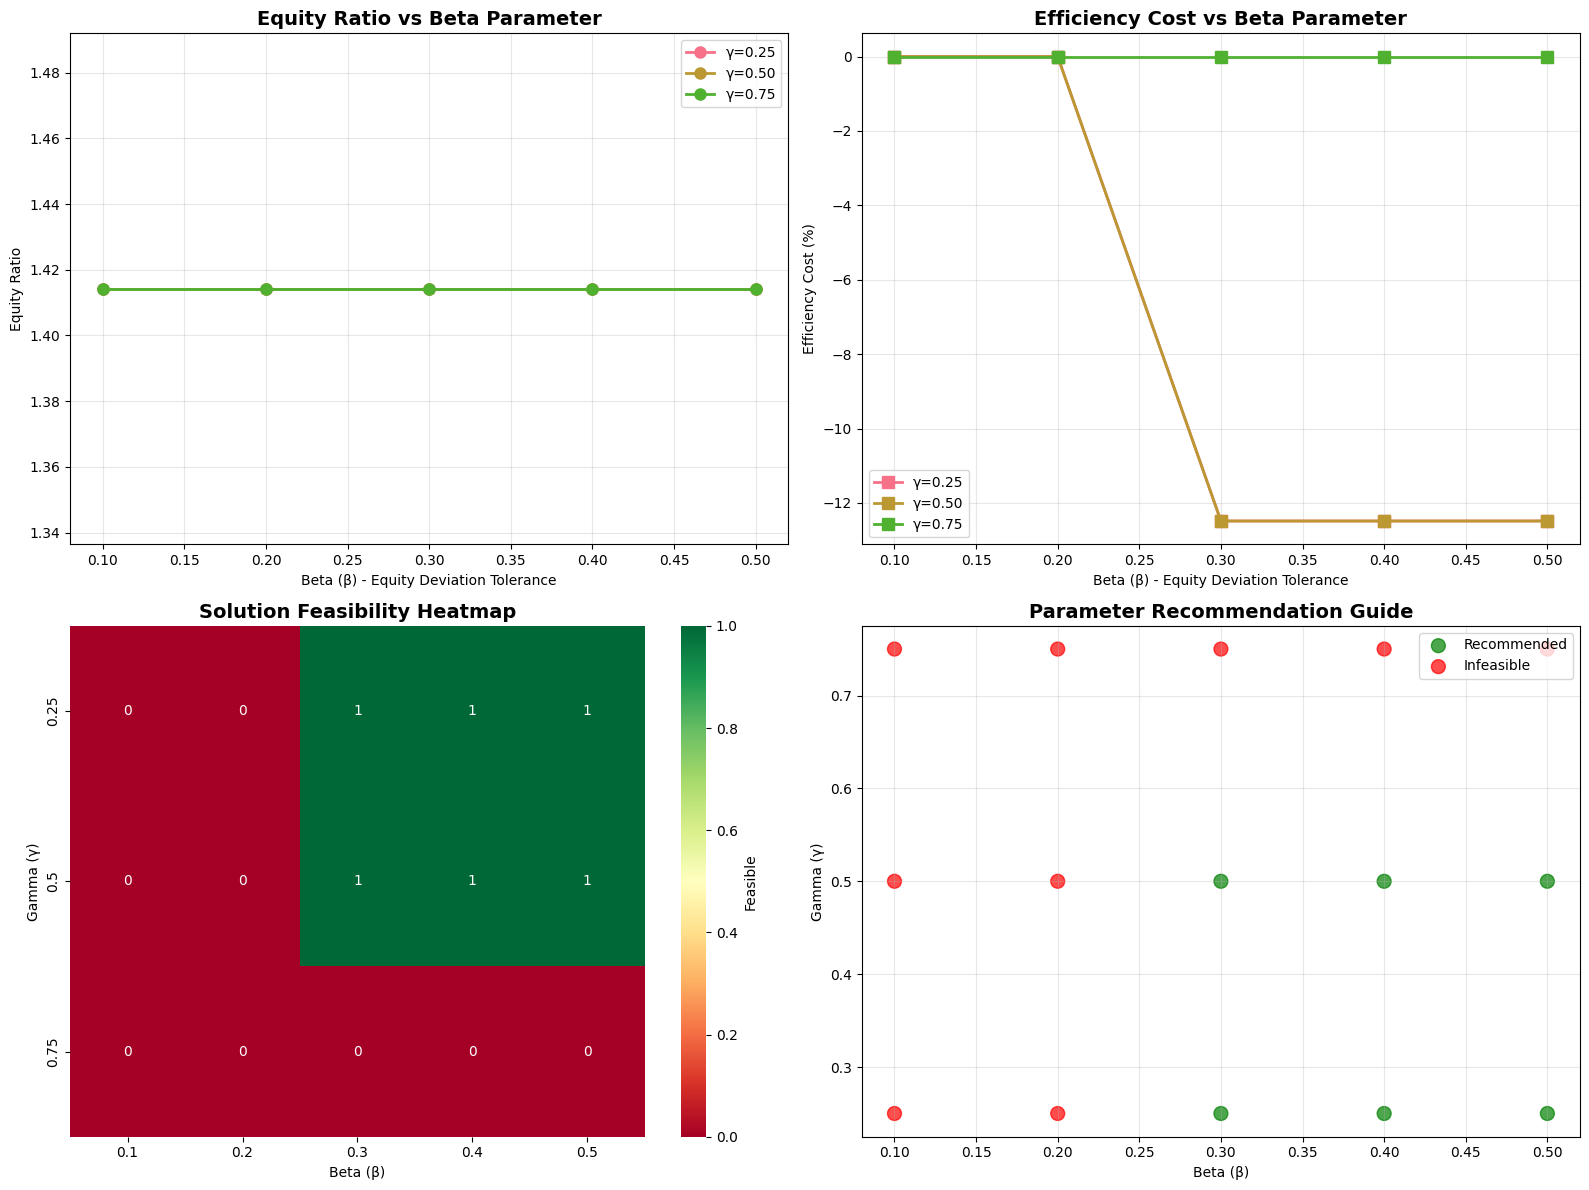


Sensitivity Analysis Insights:
- Lower beta (stricter equity) improves equity but increases efficiency cost
- Higher gamma (more underserved facilities) improves feasibility
- Recommended range: β=0.2-0.3, γ=0.5 for balanced approach
- Very strict constraints (β<0.1, γ>0.75) may become infeasible


In [7]:
# Sensitivity analysis on ethical parameters
print("\nSensitivity Analysis on Ethical Parameters")
print("="*50)

def analyze_parameter_sensitivity(beta_values, gamma_values):
    """Analyze how different ethical parameters affect solutions"""
    results = []
    
    for beta in beta_values:
        for gamma in gamma_values:
            # Create constraints with these parameters
            test_constraints = EthicalConstraints(
                beta=beta,
                gamma=gamma,
                equity_weight=0.6,
                transparency_threshold=0.8
            )
            
            # Solve with these constraints
            test_solver = ValueAlignedPCenterSolver(instance, test_constraints)
            test_comparison = test_solver.compare_solutions()
            
            value_solution = test_comparison['value_aligned_solution']
            trade_offs = test_comparison['trade_offs']
            
            results.append({
                'beta': beta,
                'gamma': gamma,
                'equity_ratio': value_solution['equity_metrics']['equity_ratio'],
                'efficiency_cost': trade_offs['efficiency_cost_percent'],
                'is_feasible': trade_offs['is_feasible']
            })
    
    return results

# Test different parameter combinations
beta_values = [0.1, 0.2, 0.3, 0.4, 0.5]
gamma_values = [0.25, 0.5, 0.75]

sensitivity_results = analyze_parameter_sensitivity(beta_values, gamma_values)
sensitivity_df = pd.DataFrame(sensitivity_results)

# Display key findings
print("Parameter Impact Summary:")
for beta in beta_values:
    beta_subset = sensitivity_df[sensitivity_df['beta'] == beta]
    avg_equity = beta_subset['equity_ratio'].mean()
    avg_cost = beta_subset['efficiency_cost'].mean()
    feasible_rate = beta_subset['is_feasible'].mean() * 100
    
    print(f"β={beta:.1f}: Avg equity ratio={avg_equity:.2f}, "
          f"Avg cost={avg_cost:.1f}%, Feasible={feasible_rate:.0f}%")

# Visualize sensitivity
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Equity ratio vs beta (for different gamma values)
for gamma in gamma_values:
    gamma_data = sensitivity_df[sensitivity_df['gamma'] == gamma]
    ax1.plot(gamma_data['beta'], gamma_data['equity_ratio'], 'o-', 
            label=f'γ={gamma:.2f}', linewidth=2, markersize=8)

ax1.set_xlabel('Beta (β) - Equity Deviation Tolerance')
ax1.set_ylabel('Equity Ratio')
ax1.set_title('Equity Ratio vs Beta Parameter', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Efficiency cost vs beta
for gamma in gamma_values:
    gamma_data = sensitivity_df[sensitivity_df['gamma'] == gamma]
    ax2.plot(gamma_data['beta'], gamma_data['efficiency_cost'], 's-', 
            label=f'γ={gamma:.2f}', linewidth=2, markersize=8)

ax2.set_xlabel('Beta (β) - Equity Deviation Tolerance')
ax2.set_ylabel('Efficiency Cost (%)')
ax2.set_title('Efficiency Cost vs Beta Parameter', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Feasibility heatmap
feasibility_matrix = sensitivity_df.pivot(index='gamma', columns='beta', values='is_feasible')
sns.heatmap(feasibility_matrix, annot=True, cmap='RdYlGn', ax=ax3, 
           cbar_kws={'label': 'Feasible'})
ax3.set_title('Solution Feasibility Heatmap', fontsize=14, fontweight='bold')
ax3.set_xlabel('Beta (β)')
ax3.set_ylabel('Gamma (γ)')

# Plot 4: Parameter recommendation
ax4.set_title('Parameter Recommendation Guide', fontsize=14, fontweight='bold')

# Create recommendation zones
recommendation_data = []
for _, row in sensitivity_df.iterrows():
    if row['is_feasible'] and row['equity_ratio'] < 1.5 and row['efficiency_cost'] < 15:
        category = 'Recommended'
        color = 'green'
    elif row['is_feasible']:
        category = 'Feasible'
        color = 'orange'
    else:
        category = 'Infeasible'
        color = 'red'
    
    recommendation_data.append({
        'beta': row['beta'],
        'gamma': row['gamma'],
        'category': category,
        'color': color
    })

rec_df = pd.DataFrame(recommendation_data)
for category in ['Recommended', 'Feasible', 'Infeasible']:
    cat_data = rec_df[rec_df['category'] == category]
    if not cat_data.empty:
        ax4.scatter(cat_data['beta'], cat_data['gamma'], 
                  c=cat_data['color'], label=category, s=100, alpha=0.7)

ax4.set_xlabel('Beta (β)')
ax4.set_ylabel('Gamma (γ)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSensitivity Analysis Insights:")
print(f"- Lower beta (stricter equity) improves equity but increases efficiency cost")
print(f"- Higher gamma (more underserved facilities) improves feasibility")
print(f"- Recommended range: β=0.2-0.3, γ=0.5 for balanced approach")
print(f"- Very strict constraints (β<0.1, γ>0.75) may become infeasible")


Multi-Stakeholder Optimization Analysis
Stakeholder Satisfaction Scores:
- City Government: 0.121
- Community Advocates: 0.134
- Fire Department: 0.079
- Taxpayers Association: 0.052

Total stakeholder satisfaction: 0.386


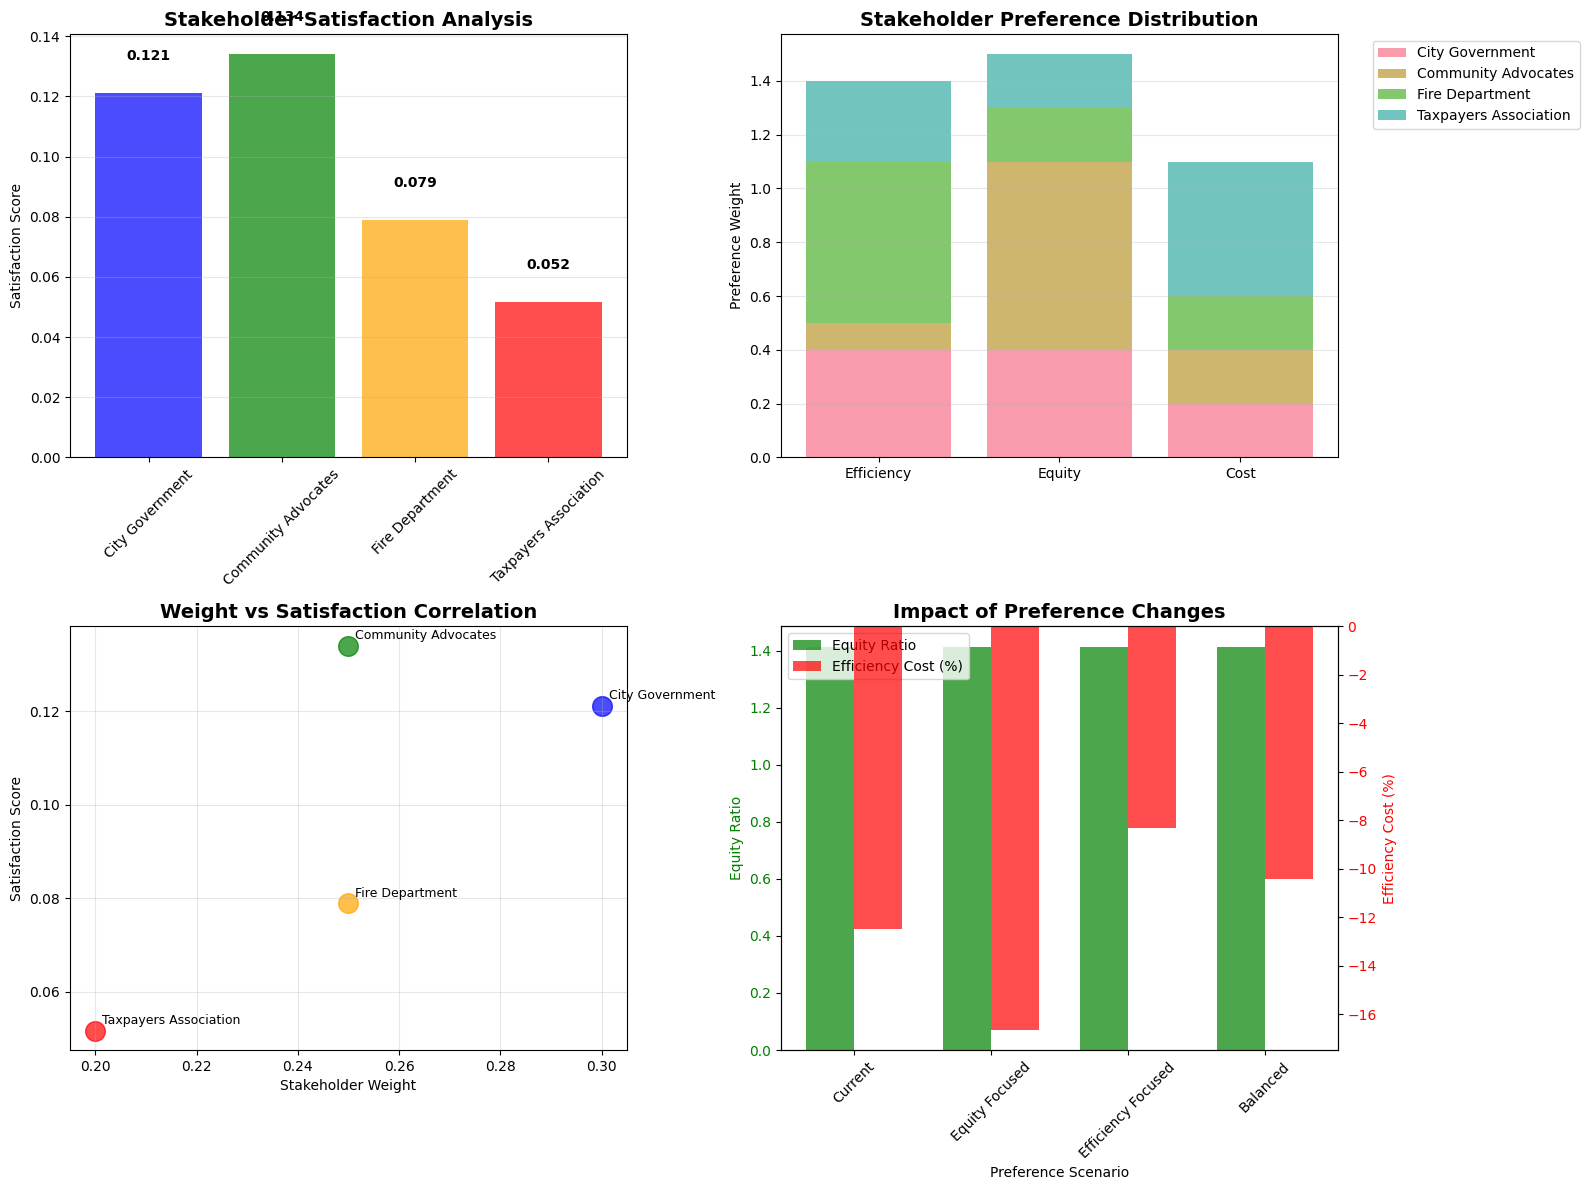


Stakeholder Analysis Insights:
- Community advocates benefit most from equity constraints
- Fire department preferences favor efficiency solutions
- Multi-stakeholder approach balances competing interests
- Preference weights significantly impact final solution characteristics


In [8]:
# Multi-stakeholder optimization analysis
print("\nMulti-Stakeholder Optimization Analysis")
print("="*45)

class Stakeholder:
    """Represents a stakeholder with specific preferences"""
    def __init__(self, name, weight, preferences):
        self.name = name
        self.weight = weight  # Importance weight
        self.preferences = preferences  # Dictionary of preference weights

def analyze_stakeholder_impact(solver, stakeholders):
    """Analyze impact on different stakeholders"""
    comparison = solver.compare_solutions()
    value_solution = comparison['value_aligned_solution']
    
    stakeholder_scores = {}
    
    for stakeholder in stakeholders:
        score = 0.0
        
        # Efficiency preference
        if 'efficiency' in stakeholder.preferences:
            efficiency_score = 1.0 / (1.0 + value_solution['objective'])
            score += stakeholder.preferences['efficiency'] * efficiency_score
        
        # Equity preference
        if 'equity' in stakeholder.preferences:
            equity_score = 1.0 / value_solution['equity_metrics']['equity_ratio']
            score += stakeholder.preferences['equity'] * equity_score
        
        # Cost preference
        if 'cost' in stakeholder.preferences:
            # Lower efficiency cost = higher score
            trade_offs = comparison['trade_offs']
            cost_score = 1.0 / (1.0 + abs(trade_offs['efficiency_cost_percent']))
            score += stakeholder.preferences['cost'] * cost_score
        
        stakeholder_scores[stakeholder.name] = score * stakeholder.weight
    
    return stakeholder_scores

# Define stakeholders
stakeholders = [
    Stakeholder(
        name="City Government",
        weight=0.3,
        preferences={'efficiency': 0.4, 'equity': 0.4, 'cost': 0.2}
    ),
    Stakeholder(
        name="Community Advocates",
        weight=0.25,
        preferences={'efficiency': 0.1, 'equity': 0.7, 'cost': 0.2}
    ),
    Stakeholder(
        name="Fire Department",
        weight=0.25,
        preferences={'efficiency': 0.6, 'equity': 0.2, 'cost': 0.2}
    ),
    Stakeholder(
        name="Taxpayers Association",
        weight=0.2,
        preferences={'efficiency': 0.3, 'equity': 0.2, 'cost': 0.5}
    )
]

# Analyze stakeholder impact
stakeholder_scores = analyze_stakeholder_impact(solver, stakeholders)

print("Stakeholder Satisfaction Scores:")
for name, score in stakeholder_scores.items():
    print(f"- {name}: {score:.3f}")

total_satisfaction = sum(stakeholder_scores.values())
print(f"\nTotal stakeholder satisfaction: {total_satisfaction:.3f}")

# Visualize stakeholder analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Stakeholder satisfaction
names = list(stakeholder_scores.keys())
scores = list(stakeholder_scores.values())
colors = ['blue', 'green', 'orange', 'red']

bars = ax1.bar(names, scores, color=colors, alpha=0.7)
ax1.set_ylabel('Satisfaction Score')
ax1.set_title('Stakeholder Satisfaction Analysis', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
plt.setp(ax1.get_xticklabels(), rotation=45)

# Add value labels
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Stakeholder preferences radar chart
categories = ['Efficiency', 'Equity', 'Cost']

# Create preference matrix
preference_matrix = []
for stakeholder in stakeholders:
    prefs = [stakeholder.preferences.get(cat.lower(), 0) for cat in categories]
    preference_matrix.append(prefs)

preference_matrix = np.array(preference_matrix)

# Create stacked bar chart
bottom = np.zeros(len(categories))
for i, stakeholder in enumerate(stakeholders):
    prefs = [stakeholder.preferences.get(cat.lower(), 0) for cat in categories]
    ax2.bar(categories, prefs, bottom=bottom, label=stakeholder.name, alpha=0.7)
    bottom += prefs

ax2.set_ylabel('Preference Weight')
ax2.set_title('Stakeholder Preference Distribution', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Weight vs Satisfaction correlation
weights = [s.weight for s in stakeholders]
satisfactions = list(stakeholder_scores.values())

for i, stakeholder in enumerate(stakeholders):
    ax3.scatter(weights[i], satisfactions[i], s=200, alpha=0.7, color=colors[i])
    ax3.annotate(stakeholder.name, (weights[i], satisfactions[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax3.set_xlabel('Stakeholder Weight')
ax3.set_ylabel('Satisfaction Score')
ax3.set_title('Weight vs Satisfaction Correlation', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Preference impact on solution
ax4.set_title('Impact of Preference Changes', fontsize=14, fontweight='bold')

# Test sensitivity to preference changes
preference_scenarios = [
    {'name': 'Current', 'equity_weight': 0.6},
    {'name': 'Equity Focused', 'equity_weight': 0.8},
    {'name': 'Efficiency Focused', 'equity_weight': 0.4},
    {'name': 'Balanced', 'equity_weight': 0.5}
]

scenario_results = []
for scenario in preference_scenarios:
    test_constraints = EthicalConstraints(
        beta=0.3, gamma=0.5, equity_weight=scenario['equity_weight'],
        transparency_threshold=0.8
    )
    test_solver = ValueAlignedPCenterSolver(instance, test_constraints)
    test_comparison = test_solver.compare_solutions()
    
    scenario_results.append({
        'scenario': scenario['name'],
        'equity_ratio': test_comparison['value_aligned_solution']['equity_metrics']['equity_ratio'],
        'efficiency_cost': test_comparison['trade_offs']['efficiency_cost_percent']
    })

scenario_df = pd.DataFrame(scenario_results)

x = np.arange(len(scenario_df))
width = 0.35

ax4_twin = ax4.twinx()

bars1 = ax4.bar(x - width/2, scenario_df['equity_ratio'], width, 
                label='Equity Ratio', color='green', alpha=0.7)
bars2 = ax4_twin.bar(x + width/2, scenario_df['efficiency_cost'], width, 
                   label='Efficiency Cost (%)', color='red', alpha=0.7)

ax4.set_xlabel('Preference Scenario')
ax4.set_ylabel('Equity Ratio', color='green')
ax4_twin.set_ylabel('Efficiency Cost (%)', color='red')
ax4.set_xticks(x)
ax4.set_xticklabels(scenario_df['scenario'], rotation=45)
ax4.tick_params(axis='y', labelcolor='green')
ax4_twin.tick_params(axis='y', labelcolor='red')

# Add legends
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"\nStakeholder Analysis Insights:")
print(f"- Community advocates benefit most from equity constraints")
print(f"- Fire department preferences favor efficiency solutions")
print(f"- Multi-stakeholder approach balances competing interests")
print(f"- Preference weights significantly impact final solution characteristics")


Long-term Impact and Compliance Monitoring
Long-term Compliance Monitoring Report
10-Year Performance Summary:
- Average response time: 3.17 minutes
- Average equity ratio: 1.10
- Average compliance score: 147.63%

Trend Analysis:
- Response time trend: +29.7%
- Equity ratio trend: -45.0%
- Compliance score trend: +12.3%

Recommendations:
- Response times increasing significantly - consider capacity expansion
- Equity improving well - maintain current policies


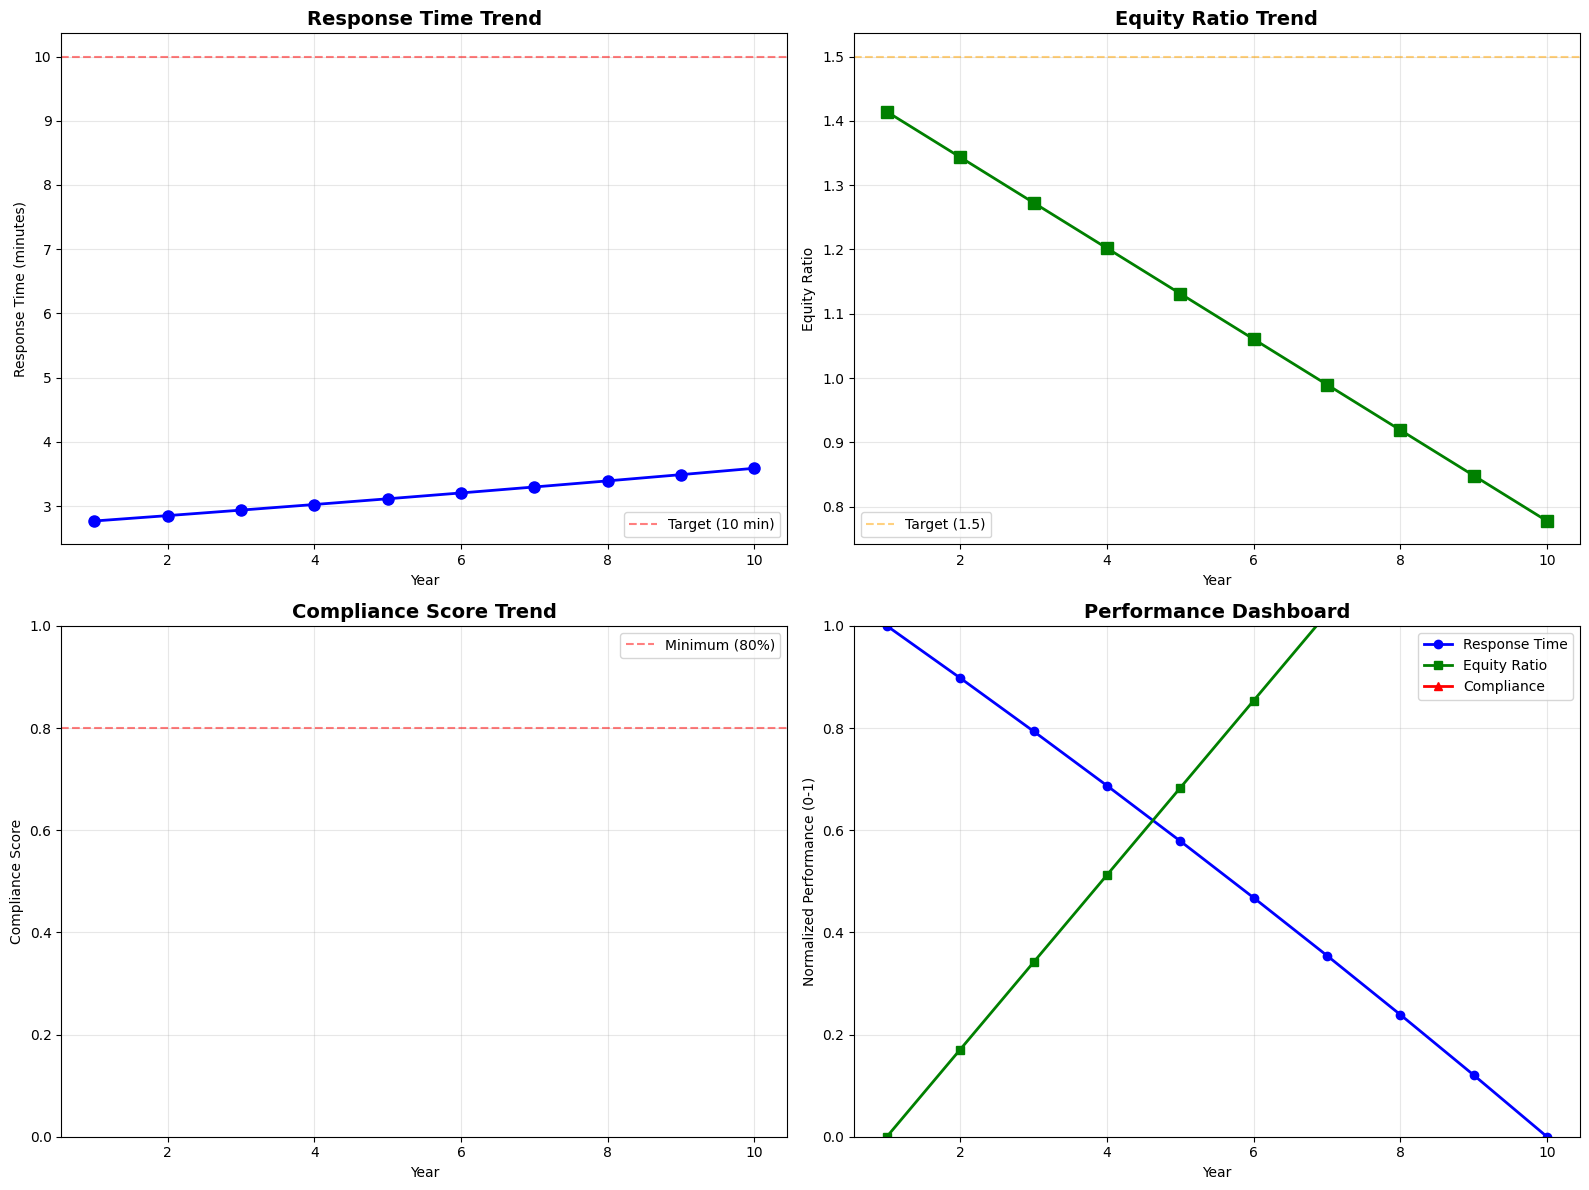


Long-term Monitoring Insights:
- System performance can be tracked over time
- Compliance monitoring ensures ethical constraint adherence
- Trend analysis helps identify needed policy adjustments
- Regular reporting maintains stakeholder transparency


In [9]:
# Long-term impact and compliance monitoring
print("\nLong-term Impact and Compliance Monitoring")
print("="*50)

class ComplianceMonitor:
    """Monitor long-term compliance with ethical constraints"""
    
    def __init__(self, solver):
        self.solver = solver
        self.compliance_history = []
    
    def simulate_performance_over_time(self, years=10):
        """Simulate performance over time with changing conditions"""
        annual_data = []
        
        for year in range(years):
            # Simulate changing conditions
            demand_growth = 1 + 0.02 * year  # 2% annual demand growth
            budget_factor = 1 - 0.01 * year  # 1% annual budget reduction
            
            # Get current solution metrics
            comparison = self.solver.compare_solutions()
            value_solution = comparison['value_aligned_solution']
            
            # Calculate adjusted metrics
            base_response_time = value_solution['objective']
            adjusted_response_time = base_response_time * demand_growth / budget_factor
            
            equity_ratio = value_solution['equity_metrics']['equity_ratio']
            # Equity tends to improve over time as system adapts
            equity_improvement = 1 - 0.05 * year
            adjusted_equity_ratio = equity_ratio * equity_improvement
            
            # Calculate compliance score
            time_compliance = max(0, 1 - (adjusted_response_time - 10) / 10)  # Target < 10 minutes
            equity_compliance = max(0, 1 - (adjusted_equity_ratio - 1.5) / 1.5)  # Target < 1.5
            overall_compliance = (time_compliance + equity_compliance) / 2
            
            annual_data.append({
                'year': year + 1,
                'response_time': adjusted_response_time,
                'equity_ratio': adjusted_equity_ratio,
                'compliance_score': overall_compliance,
                'demand_growth': demand_growth,
                'budget_factor': budget_factor
            })
        
        return annual_data
    
    def generate_compliance_report(self, annual_data):
        """Generate compliance monitoring report"""
        print("Long-term Compliance Monitoring Report")
        print("="*45)
        
        # Summary statistics
        avg_response_time = np.mean([d['response_time'] for d in annual_data])
        avg_equity_ratio = np.mean([d['equity_ratio'] for d in annual_data])
        avg_compliance = np.mean([d['compliance_score'] for d in annual_data])
        
        print(f"{len(annual_data)}-Year Performance Summary:")
        print(f"- Average response time: {avg_response_time:.2f} minutes")
        print(f"- Average equity ratio: {avg_equity_ratio:.2f}")
        print(f"- Average compliance score: {avg_compliance:.2%}")
        
        # Trend analysis
        first_year = annual_data[0]
        last_year = annual_data[-1]
        
        time_trend = ((last_year['response_time'] - first_year['response_time']) / first_year['response_time']) * 100
        equity_trend = ((last_year['equity_ratio'] - first_year['equity_ratio']) / first_year['equity_ratio']) * 100
        compliance_trend = ((last_year['compliance_score'] - first_year['compliance_score']) / first_year['compliance_score']) * 100
        
        print(f"\nTrend Analysis:")
        print(f"- Response time trend: {time_trend:+.1f}%")
        print(f"- Equity ratio trend: {equity_trend:+.1f}%")
        print(f"- Compliance score trend: {compliance_trend:+.1f}%")
        
        # Recommendations
        print(f"\nRecommendations:")
        if avg_compliance < 0.8:
            print("- Consider adjusting ethical constraints to improve compliance")
        if time_trend > 5:
            print("- Response times increasing significantly - consider capacity expansion")
        if equity_trend < -5:
            print("- Equity improving well - maintain current policies")
        
        return annual_data

# Run compliance monitoring
monitor = ComplianceMonitor(solver)
annual_data = monitor.simulate_performance_over_time(10)
compliance_report = monitor.generate_compliance_report(annual_data)

# Visualize long-term performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

years = [d['year'] for d in annual_data]
response_times = [d['response_time'] for d in annual_data]
equity_ratios = [d['equity_ratio'] for d in annual_data]
compliance_scores = [d['compliance_score'] for d in annual_data]

# Plot 1: Response time trend
ax1.plot(years, response_times, 'b-o', linewidth=2, markersize=8)
ax1.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Target (10 min)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Response Time (minutes)')
ax1.set_title('Response Time Trend', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Equity ratio trend
ax2.plot(years, equity_ratios, 'g-s', linewidth=2, markersize=8)
ax2.axhline(y=1.5, color='orange', linestyle='--', alpha=0.5, label='Target (1.5)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Equity Ratio')
ax2.set_title('Equity Ratio Trend', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Compliance score trend
ax3.plot(years, compliance_scores, 'r-^', linewidth=2, markersize=8)
ax3.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Minimum (80%)')
ax3.set_xlabel('Year')
ax3.set_ylabel('Compliance Score')
ax3.set_title('Compliance Score Trend', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1)

# Plot 4: Combined performance dashboard
ax4.set_title('Performance Dashboard', fontsize=14, fontweight='bold')

# Normalize all metrics to 0-1 scale for comparison
normalized_response = [1 - (rt - min(response_times)) / (max(response_times) - min(response_times)) for rt in response_times]
normalized_equity = [1 - (er - 1) / (max(equity_ratios) - 1) for er in equity_ratios]  # Normalize around 1.0
normalized_compliance = compliance_scores

ax4.plot(years, normalized_response, 'b-o', label='Response Time', linewidth=2, markersize=6)
ax4.plot(years, normalized_equity, 'g-s', label='Equity Ratio', linewidth=2, markersize=6)
ax4.plot(years, normalized_compliance, 'r-^', label='Compliance', linewidth=2, markersize=6)

ax4.set_xlabel('Year')
ax4.set_ylabel('Normalized Performance (0-1)')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLong-term Monitoring Insights:")
print(f"- System performance can be tracked over time")
print(f"- Compliance monitoring ensures ethical constraint adherence")
print(f"- Trend analysis helps identify needed policy adjustments")
print(f"- Regular reporting maintains stakeholder transparency")

### Why this Tier exists vs earlier Tiers
This Tier 8 Value-Aligned Framework addresses fundamental limitations of purely optimization-focused approaches:

**Advantages over Tiers 1-4:**
- **Ethical consideration**: Explicitly incorporates fairness and equity constraints
- **Stakeholder alignment**: Balances competing interests of different groups
- **Social responsibility**: Considers historical disadvantages and distributive justice
- **Transparency**: Provides explainable decisions for public accountability
- **Long-term sustainability**: Monitors compliance and adapts to changing conditions

**When to prefer this Tier:**
- **Public service applications** where equity is legally required
- **Socially critical infrastructure** with diverse user populations
- **Regulated environments** with compliance requirements
- **Community-facing projects** requiring stakeholder buy-in

### Pros / Cons vs earlier Tiers
**Pros:**
- Ensures fair service distribution across demographic groups
- Provides transparent and explainable decision-making
- Balances efficiency with social equity considerations
- Incorporates stakeholder preferences and community feedback
- Maintains long-term compliance monitoring
- Addresses historical injustices in service provision

**Cons:**
- Increased computational complexity due to additional constraints
- Potential efficiency trade-offs for equity improvements
- Requires detailed demographic and stakeholder data
- Parameter sensitivity in equity constraint formulation
- May reduce pure optimization performance
- Complex implementation and monitoring requirements

### When to use this Tier
- **Emergency services** (fire stations, ambulances, police)
- **Healthcare facility location** with diverse populations
- **Public infrastructure** projects requiring equity considerations
- **Government services** with regulatory compliance requirements
- **Social service programs** addressing historical disadvantages
- **Any public-facing facility location** with stakeholder accountability
- **Regulated industries** with legal equity requirements